In [1]:
# Import core libraries and NUGGET modules
import torch
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
import importlib
import pickle
import os
from nugget.geometries.base_geometry import compare_geometries
from scipy.spatial.distance import squareform
# from sklearn.manifold import MDS
import time
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, roc_curve
import sys
import pandas as pd

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [3]:
patd_surrogate = nugget.surrogates.LightSabre.LightSabrePATD(
        device=None,
        use_poisson=True,
        num_track_points=1000,
        domain_size=2500,
        use_max_energy_dist=True,
        use_perpendicular_distance_only=True,
        particle_mode='track',
        )
light_yield_surrogate_patd = patd_surrogate.light_yield_surrogate
lightsabre = nugget.surrogates.LightSabre.LightSabre(
                # device='cuda:1',
                use_poisson=True, 
                num_track_points=2000, 
                domain_size=2500,
                particle_mode='track',
                )
light_yield_surrogate = lightsabre.light_yield_surrogate

signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
        device=None,
        event_type='signal',
        domain_size=2500,
        E_min=1e2,
        E_max=1e8,
        energy_dist='log_uniform',
        find_exact_intersection=False,
        random_position_along_ray=True,
        uniform_zenith_sampling=True,
        )

In [6]:
importlib.reload(nugget.surrogates.LLRnet)

llr_net = nugget.surrogates.LLRnet.LLRnet(
    device=None,
    domain_size=2500,
    dim=3,
    hidden_dims=[64, 64, 64, 64, 64, 64],
    use_fourier_features=False,
    num_parallel_branches=1,
    learnable_frequencies=False,
    dropout_rate=0.05,
    learning_rate=3e-4,
    shared_mlp=False,
    use_residual_connections=True,
    signal_noise_scale=0,
    background_noise_scale=0,
    # add_relative_pos / log_scale_ly / norm_pos / log_scale_energy are unused
    # when use_rich_features=True; prepare_features_patd handles normalisation internally.
    add_relative_pos=False,
    log_scale_ly=True,
    norm_pos=True,
    log_scale_energy=True,
    
    reduce_lr_on_plateau=True,
    lr_scheduler_patience=30,
    lr_scheduler_factor=0.5,
    lr_scheduler_min_lr=1e-6,
    min_photons=1,
    num_photons_per_sample=None,
    input_charge=False,
    rel_time=False,
    input_delta_time=False,  # residual time is baked into prepare_features_patd as t_geom_min
    use_rich_features=True,
    add_distance_from_beam=False,
    use_patd=True,
)

llr_net.load_model('best_hit_llr_model_v7.pt')
# history = pickle.load(open('cascade_charge_llr_v2_training_history.pkl', 'rb'))

Building parallel network architecture:
  Input dim: 14
  Number of parallel branches: 1
  Shared MLP: False
  Branch 0 MLP with residual connections: 14 -> [64, 64, 64, 64, 64, 64] -> 64
  Final MLP: 64 -> 32 -> 1
  Total trainable parameters: 28,033


In [46]:
true_event = signal_sampler.sample_events(1)[0]
true_event['energy']

tensor([5981.7378])

NLL landscape (zenith vs azimuth): processed 5/900 landscape points
NLL landscape (zenith vs azimuth): processed 10/900 landscape points
NLL landscape (zenith vs azimuth): processed 15/900 landscape points
NLL landscape (zenith vs azimuth): processed 20/900 landscape points
NLL landscape (zenith vs azimuth): processed 25/900 landscape points
NLL landscape (zenith vs azimuth): processed 30/900 landscape points
NLL landscape (zenith vs azimuth): processed 35/900 landscape points
NLL landscape (zenith vs azimuth): processed 40/900 landscape points
NLL landscape (zenith vs azimuth): processed 45/900 landscape points
NLL landscape (zenith vs azimuth): processed 50/900 landscape points
NLL landscape (zenith vs azimuth): processed 55/900 landscape points
NLL landscape (zenith vs azimuth): processed 60/900 landscape points
NLL landscape (zenith vs azimuth): processed 65/900 landscape points
NLL landscape (zenith vs azimuth): processed 70/900 landscape points
NLL landscape (zenith vs azimuth): 

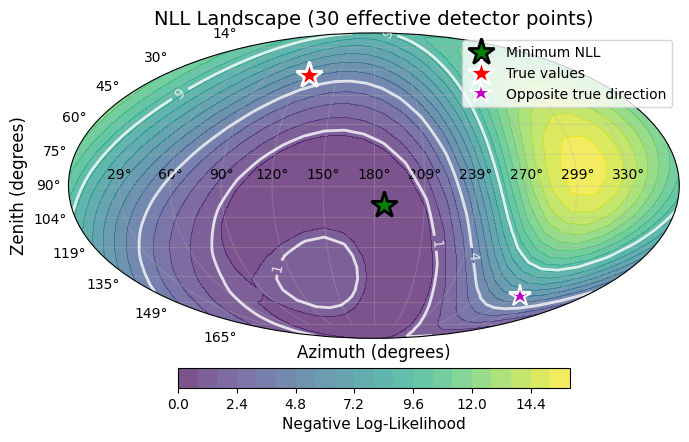

In [108]:
result = nugget.utils.vis_tools.plot_nll_landscape(
    llrnet=llr_net,
    signal_sampler=signal_sampler,
    signal_surrogate_func=light_yield_surrogate,
    event_labels=['position','energy', 'direction'],
    param_names =['zenith','azimuth'],
    # param_names=['energy'],
    # param_ranges={'energy': (1e2, 1e8)},
    param_ranges={'energy': (1e2, 1e8), 'zenith': (0, np.pi), 'azimuth': (0, 2*np.pi)},
    # param_names=['x', 'y'],
    # param_ranges={'x': (-3, 3), 'y': (-3, 3)},
    figsize=(7,5),
    n_points=30,
    detector_point=None,   
    true_event=true_event,
    use_mollweide=True,
    skip_zero_response=True,
    use_patd = False,
    use_rich_features = True,
    num_detector_points=1000, 
    min_detector_points=30,
    min_detector_response=100.0, 
    max_detector_resample_attempts=100000,
    plot_opposite_direction_true_params=True,
    progress_print_every_n_points=5    
)

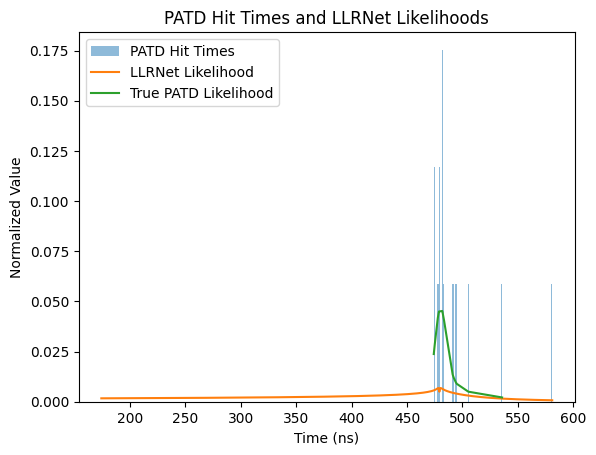

In [ ]:
num_photons = 0
while num_photons < 10:
    point = signal_sampler.sample_detector_points(1)[0]
    patd_dict = light_yield_surrogate_patd(opt_point=point, event_params=true_event)
    num_photons = patd_dict['num_photons']
test_times = torch.linspace(min(patd_dict['hit_times'])-10, max(patd_dict['hit_times']), steps=1000)
test_patd_dict = {'hit_times': test_times, 'num_photons': 1000, 't_geom_min': patd_dict['t_geom_min']}
features, num_photons = llr_net.prepare_features_patd(point=point, event_data=true_event, patd_result=test_patd_dict)
likelihoods = llr_net.predict_likelihood_ratio(features)

true_likelihoods = torch.exp(patd_surrogate.eval_patd_log_probs(patd_dict['residual_times'], point, true_event))
#plot the hit times as a histogram and the likelihoods as a line plot on the same plot
sorted_inds = torch.argsort(patd_dict['hit_times'])
true_likelihoods = true_likelihoods[sorted_inds]
true_likelihoods = true_likelihoods#/torch.sum(true_likelihoods[torch.isfinite(true_likelihoods)])
plt.hist(patd_dict['hit_times'].cpu().detach().numpy(), bins=100, alpha=0.5, label='PATD Hit Times', density=True)
normalized_likelihoods = likelihoods / (torch.sum(likelihoods*(test_times[1]-test_times[0])))
plt.plot(test_times.cpu().detach().numpy(), normalized_likelihoods.cpu().detach().numpy(), label='LLRNet Likelihood')
plt.plot(patd_dict['hit_times'][sorted_inds].cpu().detach().numpy(), true_likelihoods.cpu().detach().numpy(), label='True PATD Likelihood')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized Value')
plt.title('PATD Hit Times and LLRNet Likelihoods')
plt.legend()

True Charge: 348.00, LLRNet Predicted Charge: 308.00


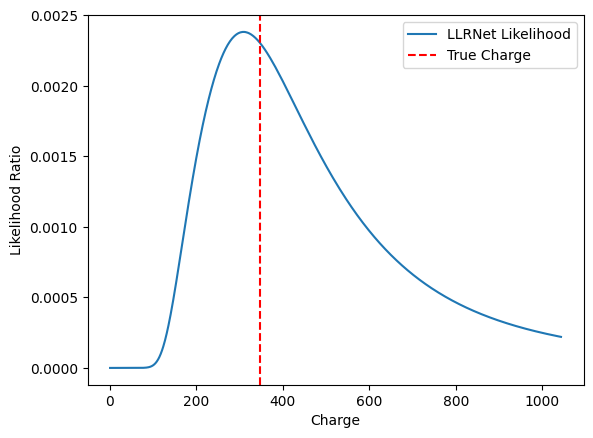

In [107]:
charge = 0
while charge <= 100:
    point = signal_sampler.sample_detector_points(1)[0]
    ly = light_yield_surrogate(opt_point=point, event_params=true_event)
    charge = ly.item()
test_charges = torch.arange(1, charge*3)
likelihoods = []
for test_charge in test_charges:
    features = llr_net.prepare_features_charge(point=point, event_data=true_event, light_yield=test_charge)
    likelihoods.append(llr_net.predict_likelihood_ratio(features))
likelihoods = torch.stack(likelihoods)
likelihoods = likelihoods / torch.sum(likelihoods)
plt.plot(test_charges.cpu().detach().numpy(), likelihoods.cpu().detach().numpy(), label='LLRNet Likelihood')
#plot vertical line at the true charge
plt.axvline(x=charge, color='red', linestyle='--', label='True Charge')
plt.xlabel('Charge')
plt.ylabel('Likelihood Ratio')
# plt.title('LLRNet Charge Likelihood')
plt.legend()
print(f'True Charge: {charge:.2f}, LLRNet Predicted Charge: {test_charges[torch.argmax(likelihoods)].item():.2f}')